In [42]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

warnings.filterwarnings("ignore")

In [43]:
df = pd.read_csv("Churn_Modelling.csv")

print("Dataset Loaded successfully")

Dataset Loaded successfully


In [44]:
# Display dataset information
print("First 5 Rows:")
display(df.head())

First 5 Rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [45]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 14)


In [46]:
print("\nDataset Information:")
df.info()



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [47]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [48]:
#Data Cleaning
# Data cleaning is performed to improve the quality of the dataset before analysis and model training.

In [49]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove unnecessary columns
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

# Display updated dataset
print("\nUpdated Shape:", df.shape)

print("\nRemaining Columns:")
print(df.columns)

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate Rows: 0

Updated Shape: (10000, 11)

Remaining Columns:
Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


In [50]:
#Exploratory Data Analysis (EDA)

# Exploratory Data Analysis (EDA) helps understand the distribution of the data and identify important patterns before 
# model building.

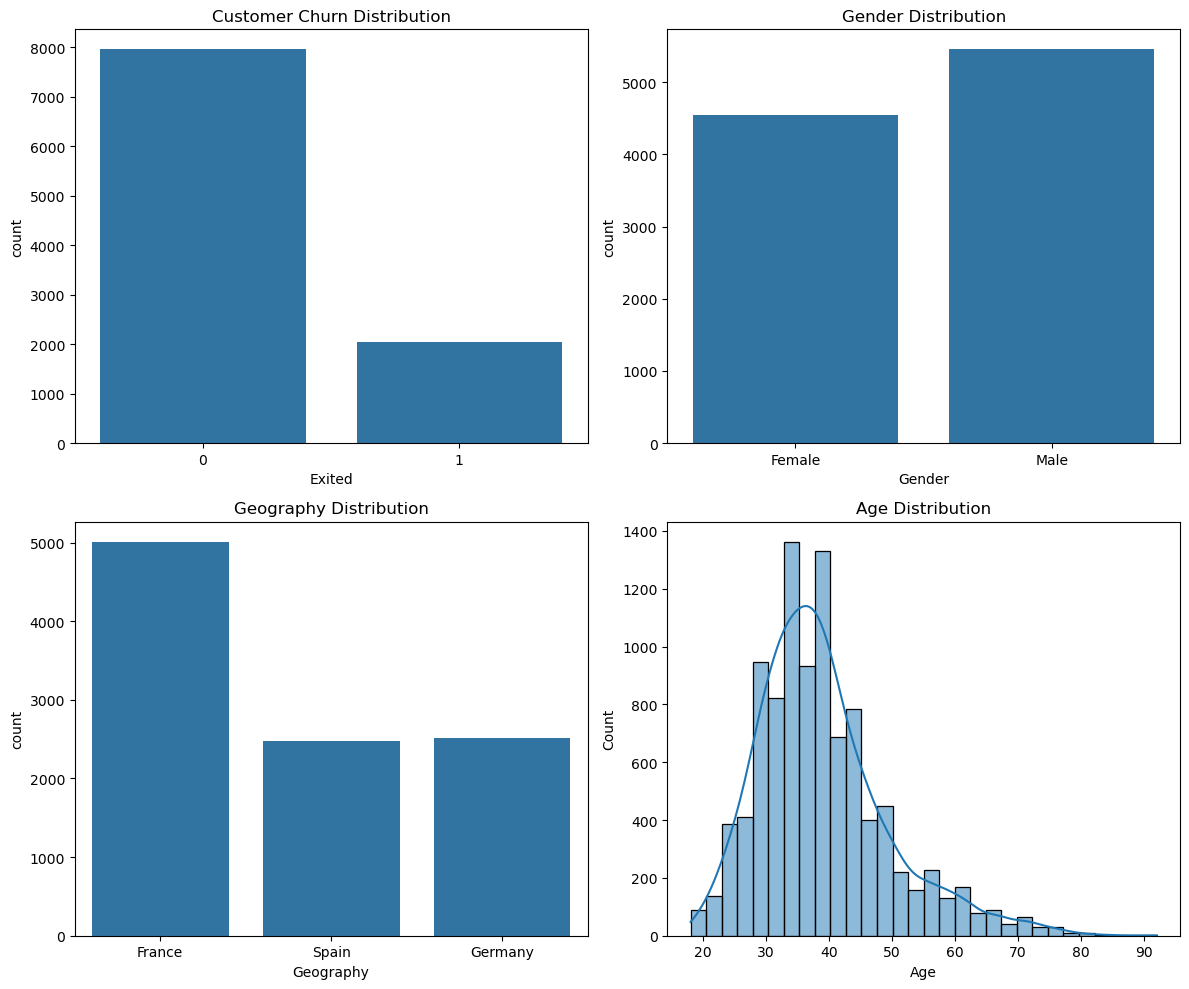

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Customer Churn Distribution
sns.countplot(data=df, x="Exited", ax=axes[0, 0])
axes[0, 0].set_title("Customer Churn Distribution")

# Gender Distribution
sns.countplot(data=df, x="Gender", ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution")

# Geography Distribution
sns.countplot(data=df, x="Geography", ax=axes[1, 0])
axes[1, 0].set_title("Geography Distribution")

# Age Distribution
sns.histplot(df["Age"], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Age Distribution")

plt.tight_layout()
plt.show()

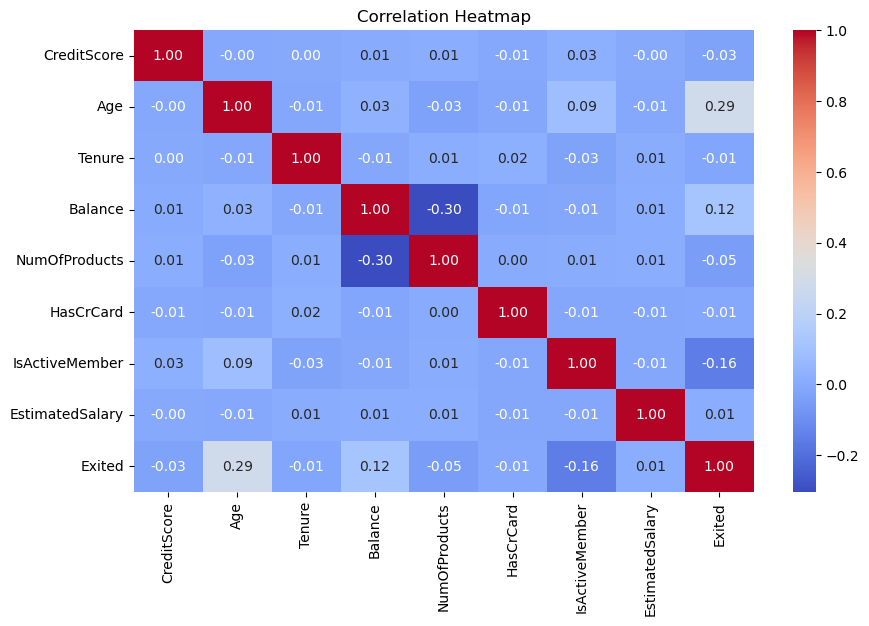

In [52]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [53]:
#Data Preprocessing

# Before training the machine learning models, the dataset is preprocessed by performing the following steps:

# - Encode categorical variables
# - Separate features and target variable
# - Split the dataset into training and testing sets
# - Normalize the feature values using StandardScaler

In [54]:

# Encode categorical variables
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

# Features and Target
X = df.drop("Exited", axis=1)
y = df["Exited"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)

Training Set Shape : (8000, 11)
Testing Set Shape  : (2000, 11)


In [55]:
## Logistic Regression

# Logistic Regression is a supervised machine learning algorithm used for binary classification problems. 
# In this project, it is used as a baseline model to predict whether a customer will leave the bank.

In [56]:
# Model Training

# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [57]:
# Evaluating the Model

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy:", round(lr_accuracy, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Accuracy: 0.811

Confusion Matrix:
[[1543   64]
 [ 314   79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



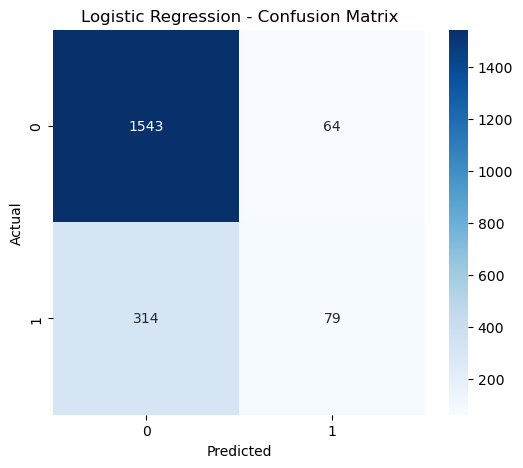

In [58]:
# Confusion Matrix Visualization

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

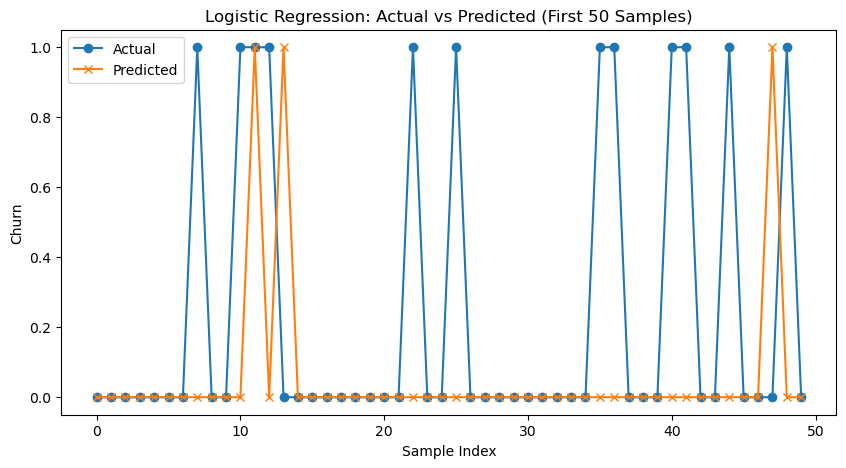

In [59]:
# Actual vs Predicted (First 50 Samples)

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label="Actual", marker="o")
plt.plot(lr_pred[:50], label="Predicted", marker="x")

plt.title("Logistic Regression: Actual vs Predicted (First 50 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Churn")
plt.legend()

plt.show()

In [60]:
#Random Forest Classifier

# Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve classification 
# accuracy and reduce overfitting. It is widely used because of its robustness and high predictive performance.

In [61]:
# Train the Model

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [62]:
# Evaluate the Model

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy:", round(rf_accuracy, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.8665

Confusion Matrix:
[[1551   56]
 [ 211  182]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



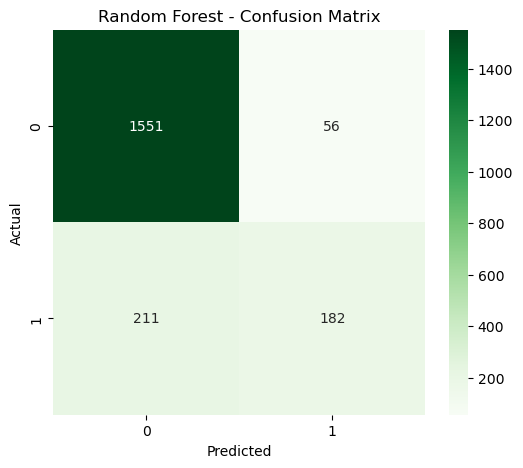

In [63]:
# Confusion Matrix Visualization

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

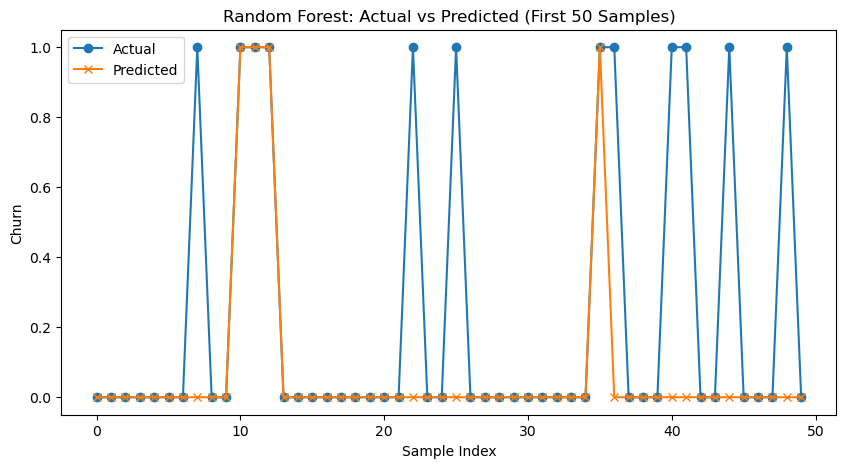

In [64]:
# Actual vs Predicted (First 50 Samples)

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label="Actual", marker="o")
plt.plot(rf_pred[:50], label="Predicted", marker="x")

plt.title("Random Forest: Actual vs Predicted (First 50 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Churn")
plt.legend()

plt.show()

In [65]:
#Artificial Neural Network (ANN)

# An Artificial Neural Network (ANN) is a deep learning model inspired by the human brain. It consists of 
# interconnected neurons organized into layers that learn complex patterns from the data to perform classification tasks.
# In this project, an ANN is trained to predict whether a bank customer will churn based on customer information.

In [66]:
# Build and Train the ANN

# Create the ANN model
ann_model = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile the model
ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train the model
history = ann_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7861 - loss: 0.5236 - val_accuracy: 0.7987 - val_loss: 0.4616
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7936 - loss: 0.4498 - val_accuracy: 0.8000 - val_loss: 0.4296
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8087 - loss: 0.4299 - val_accuracy: 0.8231 - val_loss: 0.4169
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8222 - loss: 0.4163 - val_accuracy: 0.8313 - val_loss: 0.4052
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8266 - loss: 0.4043 - val_accuracy: 0.8275 - val_loss: 0.3966
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8288 - loss: 0.3945 - val_accuracy: 0.8350 - val_loss: 0.3865
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8363 - loss: 0.3841 - val_accuracy: 0.8400 - val_loss: 0.3769
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8453 - loss: 0.3728 - val_accuracy: 0.

In [67]:
# Predict & Evaluate

# Predict probabilities
ann_pred = ann_model.predict(X_test)

# Convert probabilities to class labels
ann_pred = (ann_pred > 0.5).astype(int)

# Accuracy
ann_accuracy = accuracy_score(y_test, ann_pred)

print("Accuracy:", round(ann_accuracy, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ann_pred))

print("\nClassification Report:")
print(classification_report(y_test, ann_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy: 0.8575

Confusion Matrix:
[[1547   60]
 [ 225  168]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1607
           1       0.74      0.43      0.54       393

    accuracy                           0.86      2000
   macro avg       0.80      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000



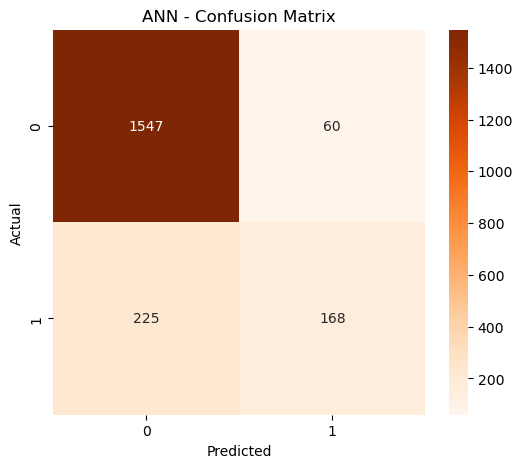

In [68]:
# Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, ann_pred),
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("ANN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

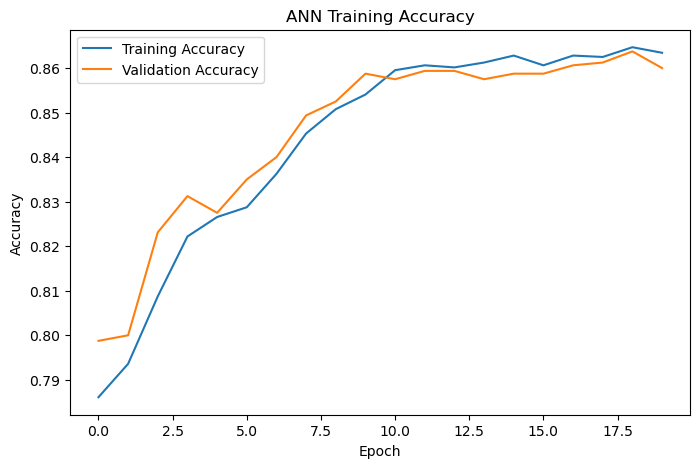

In [69]:
# Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("ANN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [70]:
#Model Comparison

# The performance of all three models is compared using common classification metrics.

# The following metrics are used:

# - Accuracy
# - Precision
# - Recall
# - F1-Score

# A comparison table and accuracy bar chart are used to identify the best-performing model.

In [71]:
# Create Comparison Table

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Artificial Neural Network"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ann_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, ann_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, ann_pred)
    ],
    "F1-Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, ann_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8110,0.552448,0.201018,0.294776
1,Random Forest,0.8665,0.764706,0.463104,0.576862
2,Artificial Neural Network,0.8575,0.736842,0.427481,0.541063


In [73]:
comparison = comparison.round(3)
comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.811,0.552,0.201,0.295
1,Random Forest,0.866,0.765,0.463,0.577
2,Artificial Neural Network,0.858,0.737,0.428,0.541


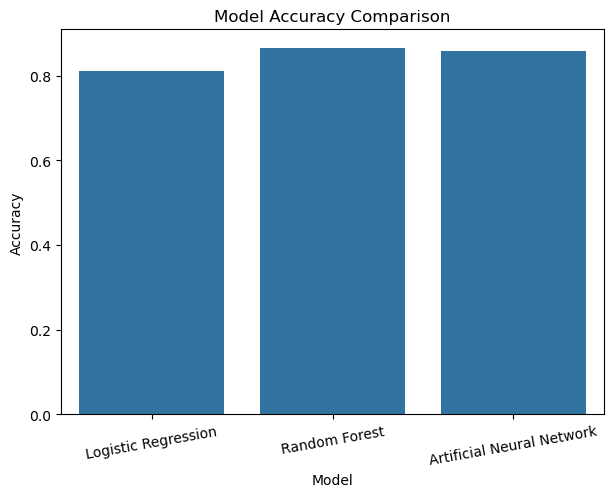

In [74]:
# Accuracy Comparison Graph

plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=10)

plt.show()

In [75]:
# Feature Importance
# Feature Importance helps identify which features contribute the most to predicting customer churn.
# The Random Forest model provides an importance score for each feature, allowing us to understand the 
# impact of different customer attributes on the prediction.

In [76]:
# Create DataFrame
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Age,0.239783
8,EstimatedSalary,0.146638
0,CreditScore,0.144214
4,Balance,0.138613
5,NumOfProducts,0.130255
3,Tenure,0.082427
7,IsActiveMember,0.041110
9,Geography_Germany,0.025711
1,Gender,0.019258
6,HasCrCard,0.018722


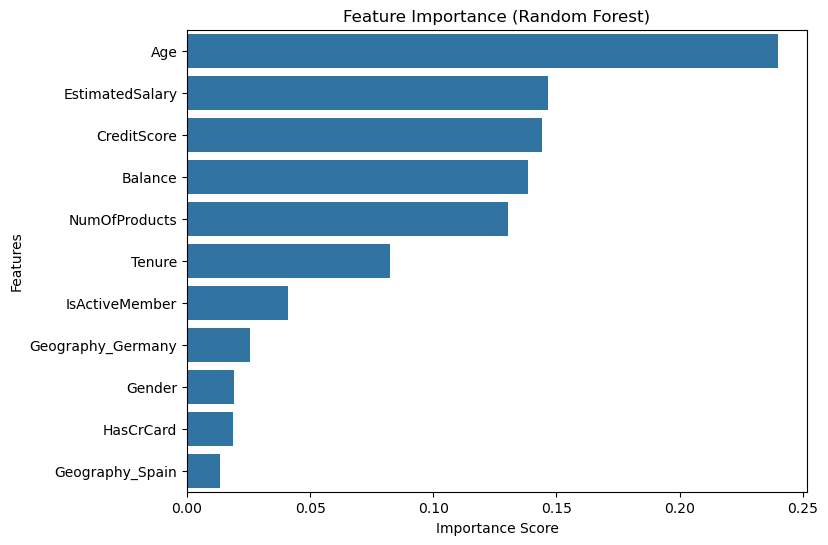

In [77]:
# Visualization

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [78]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Model :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"], 4))

Best Model : Random Forest
Accuracy   : 0.866


In [ ]:
# Conclusion

# This project successfully predicts customer churn using three different classification models:

# - Logistic Regression
# - Random Forest Classifier
# - Artificial Neural Network (ANN)

# The models were evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

# Best Performing Model

# Based on the evaluation metrics, **Random Forest Classifier** achieved the best performance with an 
# accuracy of 86.6% (0.866), outperforming both Logistic Regression and the Artificial Neural Network.

# Therefore, Random Forest Classifier is the most suitable model for predicting customer churn on this dataset.

# This project demonstrates how machine learning and deep learning techniques can help banks identify customers 
# who are likely to leave, enabling them to take proactive customer retention measures.